In [ ]:
pwd

In [7]:
# enables automatic library refreshes when importing changes to a library
%load_ext autoreload
%autoreload

In [8]:
import sys
import socket
import importlib
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from pathlib import Path

from src.config import profile_features, split_feature, num_profile_points, processed_data_path, raw_data_path
from src.preprocessing import rdp_preprocess, fit_preprocess_scalers


In [9]:

# loads raw data into a dataframe to be processed
sim = np.load(raw_data_path, allow_pickle=True)

df = pd.DataFrame(sim)

In [ ]:
'''Skip this step if data is already RDP processed'''
# runs RDP algorithm on raw data and saves it in data/processed
processed_df = rdp_preprocess(df, num_profile_points)

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
np.save(processed_data_path, processed_df)

# used to visualize which points were selected by rdp algorithm
from src.utils import varify_rdp

varify_rdp(df, processed_df)

In [10]:
# Reconstruct DataFrame from the RDP NumPy array output
processed_df = np.load(processed_data_path, allow_pickle=True)

column_headers = profile_features + [split_feature]
processed_dataframe = pd.DataFrame(processed_df, columns=column_headers)

# Normalize data
df_scaled, scalers = fit_preprocess_scalers(
    processed_dataframe,
    normalize=True,
    standardize=False,
)

arr = df_scaled.to_numpy()

Training on device: cuda
Model: VAE(
  (encoder): Sequential(
    (0): Linear(in_features=180, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
  )
  (fc_mu): Linear(in_features=64, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=256, out_features=512, bias=True)
    (7): LeakyReLU(

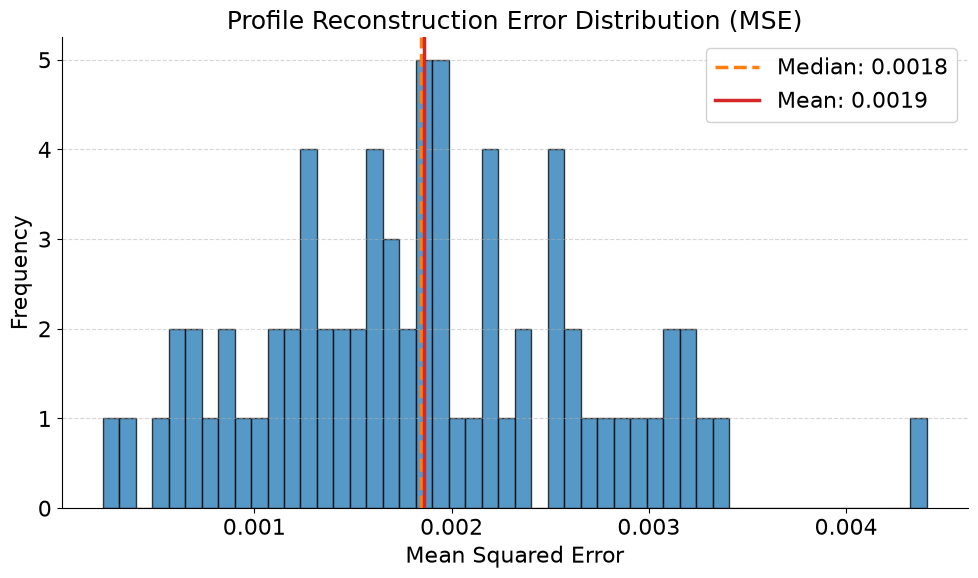

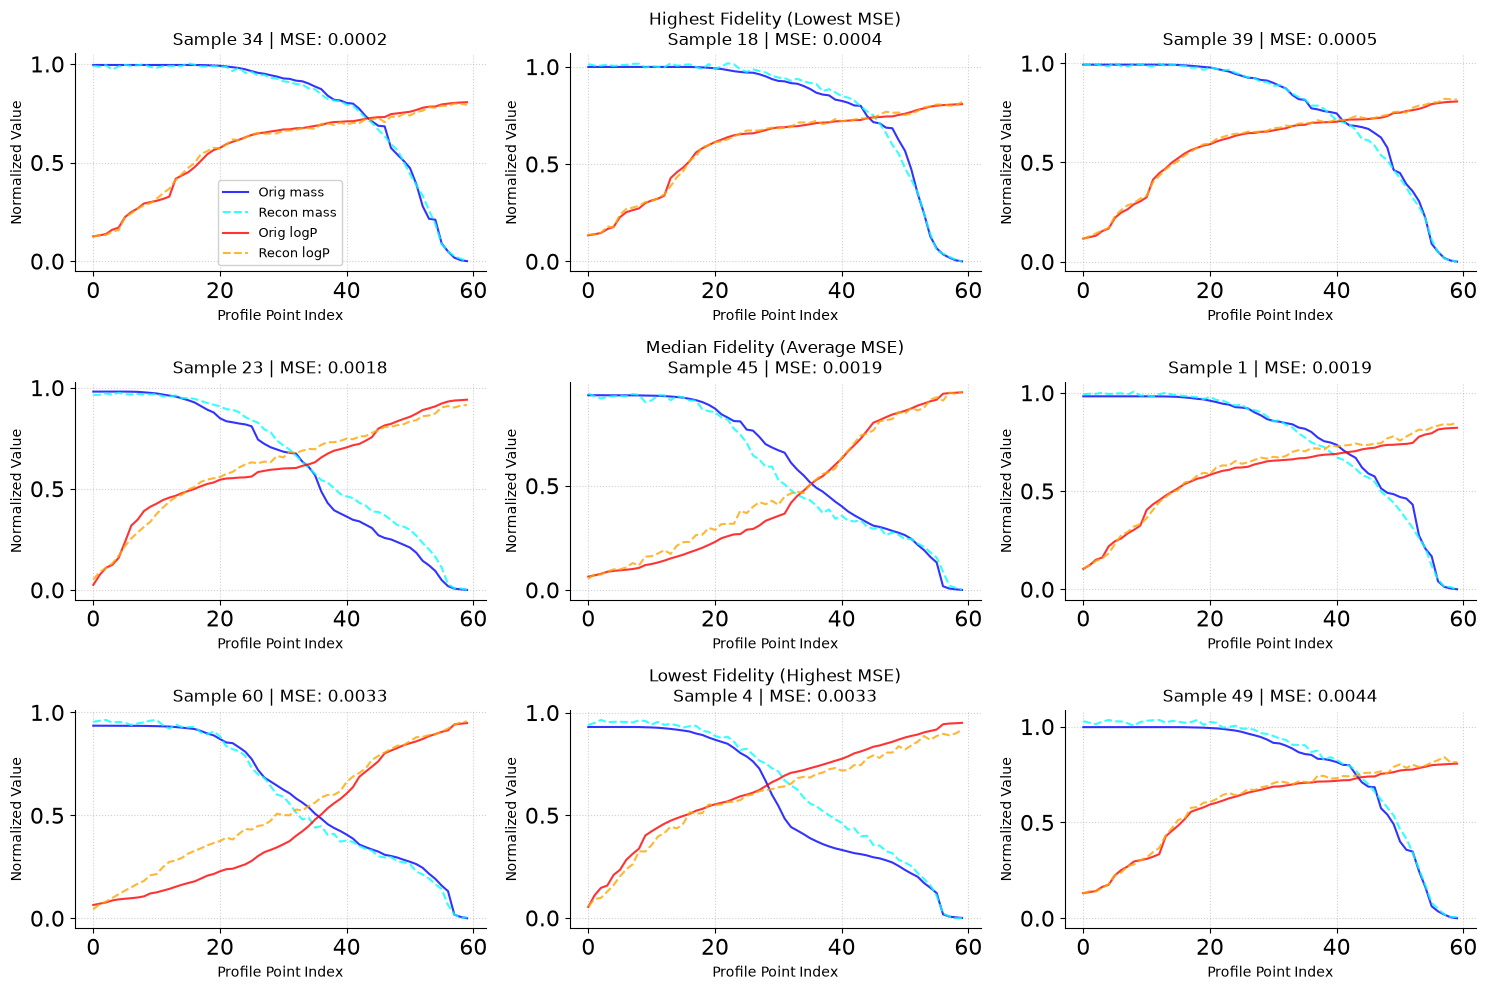

In [11]:
# Train model
from src.train import train_model
# importlib.reload(sys.modules['src.train'])
# from src.train import train_model

metrics = train_model(arr, "VAE", beta=0.125)

In [ ]:
'''SKIP THIS CELL!
Train VAE with different beta values to find the optimal trade-off between reconstruction fidelity and latent space regularization'''
import numpy as np
import pandas as pd
from src.train import train_model
from src.config import processed_data_path, profile_features, split_feature
from src.preprocessing import fit_preprocess_scalers

# Define fine-grained sequence [0.05, 0.075, ..., 0.300]
beta_candidates = np.round(np.arange(0.05, 0.325, 0.025), 3).tolist()

# Load and scale data
raw_processed_array = np.load(processed_data_path, allow_pickle=True)
column_headers = profile_features + [split_feature]
processed_dataframe = pd.DataFrame(raw_processed_array, columns=column_headers)

df_scaled, _ = fit_preprocess_scalers(
    processed_dataframe,
    normalize=True,
    standardize=False,
)
scaled_data = df_scaled.to_numpy()

hyperparameter_metrics = {}

for target_beta in beta_candidates:
    print(f"--- Initiating Sequence: Beta = {target_beta} ---")
    
    metrics = train_model(scaled_data, model="VAE", beta=target_beta, verbose=False)
    hyperparameter_metrics[target_beta] = metrics
    
    final_val_mse = metrics['val_mse'][-1]
    final_val_kld = metrics['val_kld'][-1]
    print(f"Terminal Val MSE: {final_val_mse:.4f} | Terminal Val KLD: {final_val_kld:.4f}\n")

# Extract final metrics into arrays
keys = list(hyperparameter_metrics.keys())
mse_vals = np.array([hyperparameter_metrics[b]['val_mse'][-1] for b in keys])
kld_vals = np.array([hyperparameter_metrics[b]['val_kld'][-1] for b in keys])

# Min-Max Normalize MSE and KLD to [0, 1] to prevent scale dominance
mse_norm = (mse_vals - mse_vals.min()) / (mse_vals.max() - mse_vals.min() + 1e-8)
kld_norm = (kld_vals - kld_vals.min()) / (kld_vals.max() - kld_vals.min() + 1e-8)

# Calculate Euclidean distance to ideal point (0, 0) on the Pareto frontier
# Optional weighting factor applied to MSE (1.5) to prioritize reconstruction fidelity
distances = np.sqrt(1.5 * (mse_norm ** 2) + (kld_norm ** 2))
optimal_index = np.argmin(distances)
optimal_beta = keys[optimal_index]

print(f"==========================================")
print(f"Optimal Beta (Pareto Knee Point): {optimal_beta}")
print(f"Optimal Val MSE: {mse_vals[optimal_index]:.4f}")
print(f"Optimal Val KLD: {kld_vals[optimal_index]:.4f}")
print(f"==========================================")

(<Figure size 1600x600 with 2 Axes>,
 (<Axes: title={'center': 'Reconstruction Loss (MSE)'}, xlabel='Epoch', ylabel='MSE'>,
  <Axes: title={'center': 'Latent Divergence (KLD)'}, xlabel='Epoch', ylabel='KLD'>))

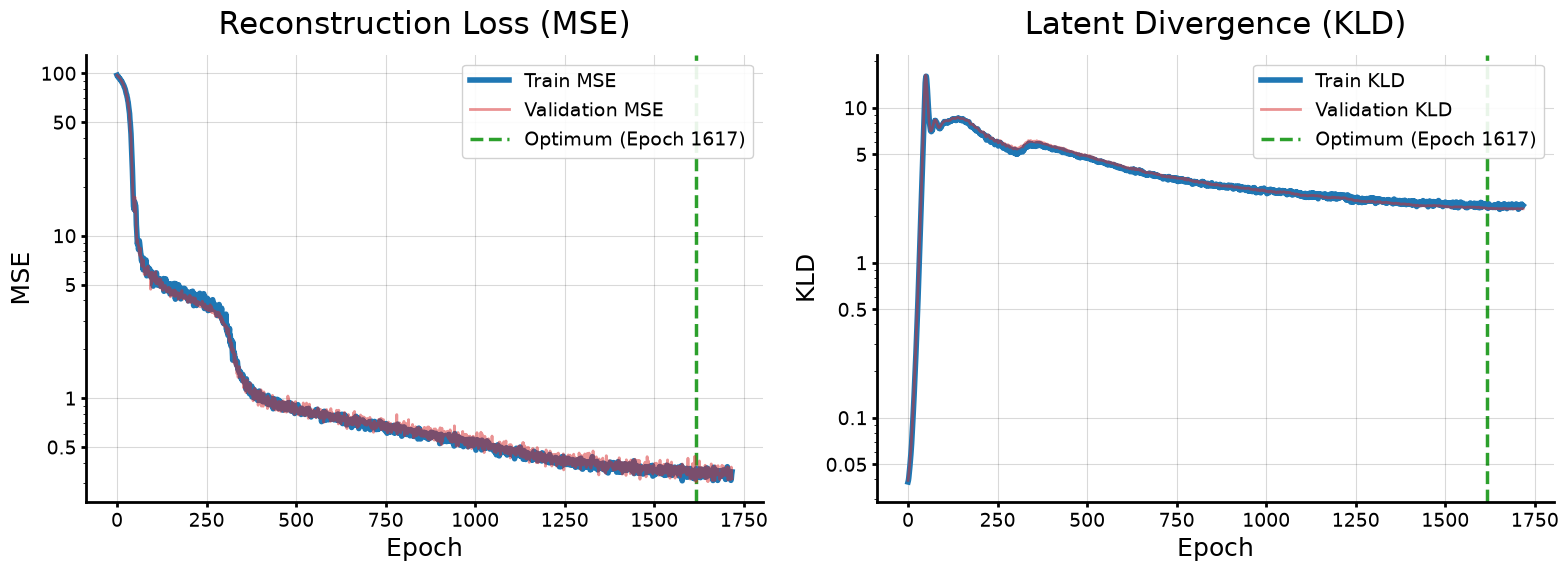

In [12]:
# Display the loss curve
# importlib.reload(sys.modules['src.utils'])
from src.utils import plot_loss_curve

plot_loss_curve(metrics)

# Note, the MSE is over all points, so the per point MES is the MSE divided by the number of points 60 * 2 for the number of features.
# The KLD is across all latent dimensions, so the per dimension KLD is the KLD divided by the number of dimensions (8).

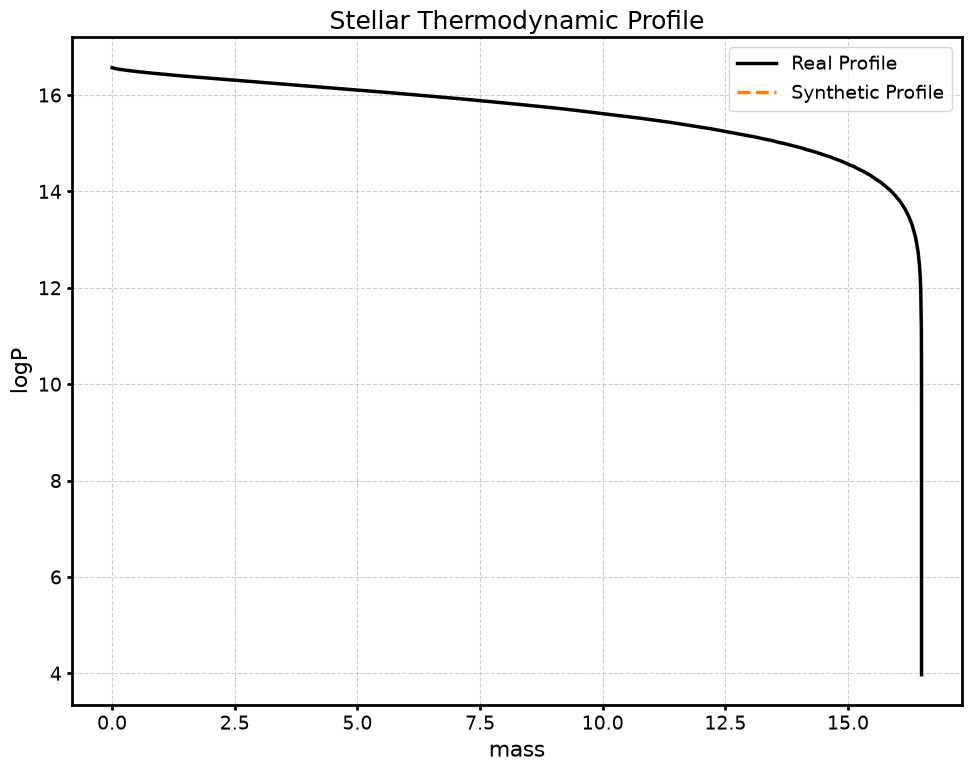

In [13]:
# Compaire the original and reconstructed profiles
from src.utils import plot_profile_reconstruction

plot_profile_reconstruction(scalers)

In [ ]:
# Visualize the latent space of the VAE model
# importlib.reload(sys.modules['src.utils'])
from src.utils import visualize_latent_space

# Default reduction method is t-SNE, but PCA can also be used for interpretability
visualize_latent_space("TSNE")